2. Analise a série UnempRate do pacote astsa do R, também disponpivel aqui. Aplique teste de raíz unitária,
e verifique a existência ou não de outliers. Por fim, faça previsões. Essa série apresenta valores mensais de
desempregados.

3. Para a série UnempRate Façaa previsões usando algum modelo de alisamento exponencial.

4. Compare as previsões dos dois ajustes anteriores.

---
## 1. Carregamento e Visualização

Convertemos para `ts` com `frequency = 12` (série mensal).  
Se os seus dados tiverem uma coluna de datas, ajuste `start = c(ANO, MES)`.

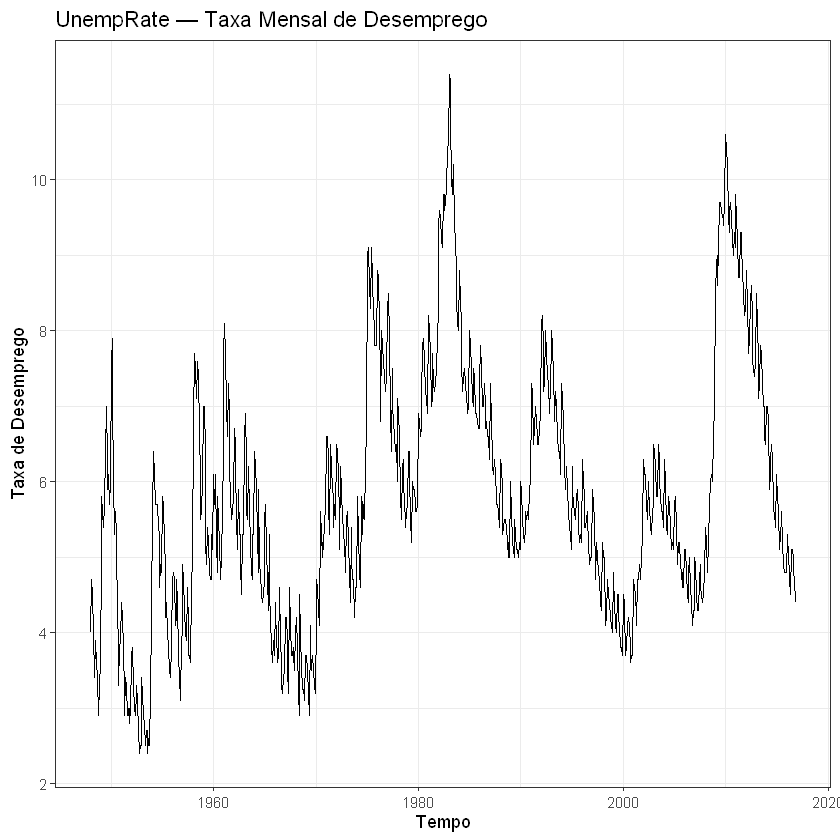

In [20]:
library(astsa)
library(tseries)
library(ggplot2)
data(UnempRate)
#library(readxl)
#dados <- read_excel("lista4.xlsx")
#serie <- ts(dados$X)
serie <- UnempRate
# Série completa
autoplot(serie) +
  ggtitle("UnempRate — Taxa Mensal de Desemprego") +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  theme_bw()


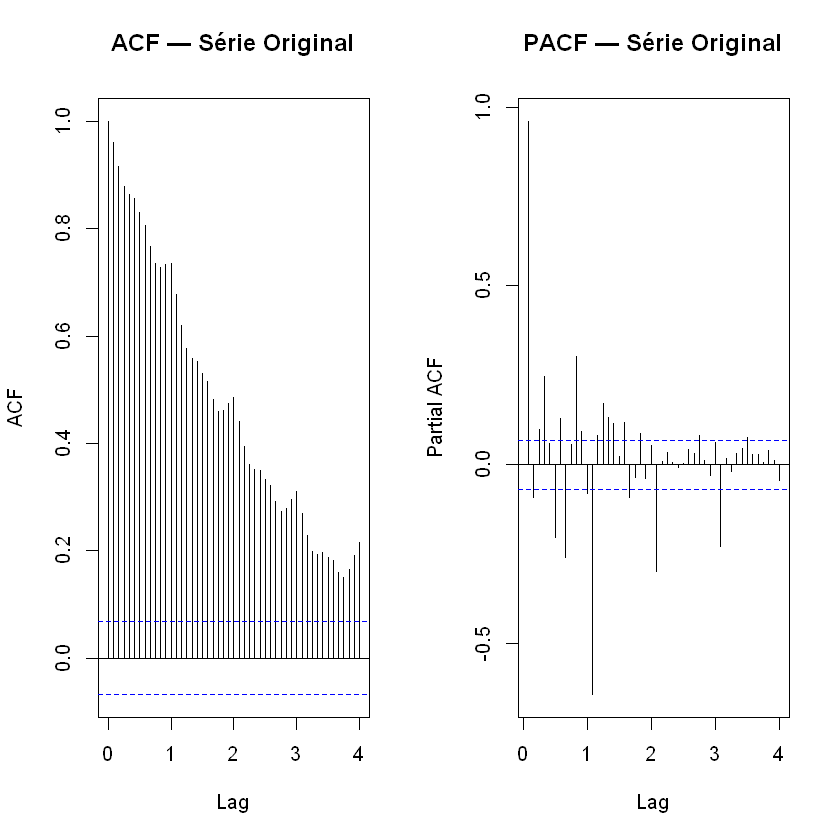

In [21]:
# ACF e PACF — decaimento lento da ACF indica não-estacionariedade
par(mfrow = c(1, 2))
acf(serie,  lag.max = 48, main = "ACF — Série Original")
pacf(serie, lag.max = 48, main = "PACF — Série Original")
par(mfrow = c(1, 1))

---
## 2. Questão 2 — Raiz Unitária, *Outliers* e ARIMA

### 2.1 Testes de raiz unitária

| Teste | H₀ | Sinal de raiz unitária |
|-------|----|-----------------------|
| **ADF** | Raiz unitária | p-valor **grande** (não rejeita) |
| **KPSS** | Estacionária | p-valor **pequeno** (rejeita) |

**Usando R temos o seguinte resultado**:

```
=== Teste ADF ===

	Augmented Dickey-Fuller Test

data:  serie
Dickey-Fuller = -2.5923, Lag order = 9, p-value = 0.3276
alternative hypothesis: stationary


Interpretação ADF: p = 0.3276 → NÃO rejeita H0 → evidência de raiz unitária.

=== Teste KPSS ===

	KPSS Test for Level Stationarity

data:  serie
KPSS Level = 1.8274, Truncation lag parameter = 6, p-value = 0.01


Interpretação KPSS: p = 0.01 → Rejeita H0 → evidência de raiz unitária.

```

Note que há evidências de que a série não é estacionária, possui raíz unitária.

**Usando R nós descobrimos que**:

```
Diferenciações sugeridas: 1 

Após diferenciar (d = 1 ):
  ADF  p = 0.01
  KPSS p = 0.1 

```
Ou seja, fizemos uma diferenciação e a série ficou estacionária.

### 2.2 Detecção de *Outliers*

Usamos a função `tso` do pacote "tsoutliers" do R

`tso()` testa quatro tipos de anomalia:

- **AO** (*Additive Outlier*) — pico/vale pontual isolado  
- **IO** (*Innovational Outlier*) — choque que se propaga  
- **LS** (*Level Shift*) — mudança permanente no nível  
- **TC** (*Temporary Change*) — mudança que decai gradualmente

**Resultado usando R**:

```
Detectando outliers...
Series: serie 
Regression with ARIMA(4,0,0)(2,1,1)[12] errors 

Coefficients:
         ar1     ar2      ar3      ar4    sar1    sar2     sma1   IO325
      1.0861  0.0924  -0.0873  -0.1154  0.0408  0.0456  -0.7929  1.2694
s.e.  0.0354  0.0525   0.0519   0.0350  0.0615  0.0528   0.0481  0.2312

sigma^2 = 0.05328:  log likelihood = 35.92
AIC=-53.85   AICc=-53.62   BIC=-11.52

Outliers:
  type ind  time coefhat tstat
1   IO 325 28:01   1.269  5.49
```
Note que temos um outlier do tipo IO (Innovational Outlier). Nós vamos prosseguir com auto.arima() na série original, isso pode dar certo, mas ao mesmo tempo estamos deixando o outlier influenciar a escolha do modelo.


![outlier](2_outlier.png)

### 2.3 Ajuste ARIMA e Previsões

`auto.arima()` busca a ordem $(p,d,q)(P,D,Q)_s$ que minimiza o AIC.

**Usando R temos**:

```
Ajustando ARIMA...
Series: serie 
ARIMA(3,0,1)(0,1,1)[12] 

Coefficients:
         ar1      ar2      ar3      ma1     sma1
      1.6979  -0.5957  -0.1132  -0.6197  -0.7538
s.e.  0.0908   0.1312   0.0469   0.0872   0.0268

sigma^2 = 0.05448:  log likelihood = 25.3
AIC=-38.59   AICc=-38.49   BIC=-10.37

Training set error measures:
                      ME     RMSE       MAE          MPE     MAPE      MASE
Training set 0.003227908 0.231003 0.1753853 -0.003109258 3.289598 0.1996076
                    ACF1
Training set 0.003210108

```

Como esse modelo ARIMA(3,0,1)(0,1,1)[12] vamos ver os respiduos.

**Teste de Ljung-Box de lag1 a 24**:

```
	Ljung-Box test

data:  Residuals from ARIMA(3,0,1)(0,1,1)[12]
Q* = 21.097, df = 19, p-value = 0.3315

Model df: 5.   Total lags used: 24

```

![residuos.png](2_residuos.png)

### Previsões feitas com o modelo:


```
=== Previsões ARIMA ===
       Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Dec 69       4.481716 4.182584 4.780849 4.024232 4.939200
Jan 70       5.176881 4.737010 5.616753 4.504156 5.849606
Feb 70       5.071831 4.497445 5.646218 4.193383 5.950279
Mar 70       4.920573 4.219967 5.621179 3.849089 5.992057
Apr 70       4.445259 3.626045 5.264472 3.192380 5.698137
May 70       4.583398 3.653461 5.513334 3.161183 6.005613
Jun 70       5.079853 4.047253 6.112452 3.500628 6.659078
Jul 70       5.224775 4.097624 6.351925 3.500947 6.948602
Aug 70       5.057826 3.844151 6.271500 3.201671 6.913980
Sep 70       4.816624 3.524250 6.108999 2.840108 6.793141
Oct 70       4.779136 3.415588 6.142685 2.693769 6.864504
Nov 70       4.744449 3.316886 6.172012 2.561179 6.927718

```

![previsoes.png](2_previsoes.png)

---
## 3. Questão 3 — Holt-Winters

Uma das opções é O método de **Holt-Winters**:


Há duas variantes:

| Variante | Quando usar | Equação sazonal |
|----------|-------------|----------------|
| **Aditivo** | Amplitude sazonal constante | $\hat{y} = (\ell + bh) + s$ |
| **Multiplicativo** | Amplitude cresce com o nível | $\hat{y} = (\ell + bh) \times s$ |

Vamos ajustar **ambos** e comparar pelo AIC.

**Usando R**:

```
=== Holt-Winters Aditivo ===
Holt-Winters' additive method 

Call:
hw(y = serie, h = h_prev, seasonal = "additive", level = c(80, 
    95))

  Smoothing parameters:
    alpha = 0.8539 
    beta  = 0.0014 
    gamma = 0.1458 

  Initial states:
    l = 2.5948 
    b = -0.0096 
    s = -0.6752 -0.3594 -0.6546 -0.2958 -0.3413 0.1712
           0.2713 -0.3058 0.2478 0.483 0.8937 0.5652

  sigma:  0.2655

     AIC     AICc      BIC 
3380.334 3381.090 3460.536 

Training set error measures:
                      ME      RMSE       MAE        MPE    MAPE     MASE
...
AIC Aditivo       : 3380.33 
AIC Multiplicativo : 3683.65 

→ Modelo selecionado: Holt-Winters Aditivo 
```

Pelo AIC vamos escolhero HoltWinters Aditivo.

```
Parâmetros Holt-Winters Aditivo :
  alpha (nível)     = 0.8539 
  beta  (tendência) = 0.0014 
  gamma (sazonal)   = 0.1458 
```

![residuos.png](3_residuos.png)

Previsões:


```
=== Previsões Holt-Winters Aditivo ===
       Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Dec 69       4.547868 4.207554 4.888182 4.027402 5.068334
Jan 70       5.269040 4.821238 5.716842 4.584186 5.953894
Feb 70       5.159907 4.625571 5.694243 4.342711 5.977103
Mar 70       4.968898 4.359982 5.577814 4.037642 5.900155
Apr 70       4.458090 3.782576 5.133604 3.424981 5.491200
May 70       4.576234 3.839935 5.312532 3.450162 5.702305
Jun 70       5.017027 4.224418 5.809636 3.804836 6.229218
Jul 70       5.062682 4.217342 5.908023 3.769846 6.355519
Aug 70       4.781447 3.886322 5.676572 3.412471 6.150423
Sep 70       4.458563 3.516132 5.400995 3.017239 5.899888
Oct 70       4.383499 3.395884 5.371114 2.873072 5.893926
Nov 70       4.363174 3.332219 5.394129 2.786464 5.939884

```
### Previsões feitas com o modelo:


```
=== Previsões ARIMA ===
       Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Dec 69       4.481716 4.182584 4.780849 4.024232 4.939200
Jan 70       5.176881 4.737010 5.616753 4.504156 5.849606
Feb 70       5.071831 4.497445 5.646218 4.193383 5.950279
Mar 70       4.920573 4.219967 5.621179 3.849089 5.992057
Apr 70       4.445259 3.626045 5.264472 3.192380 5.698137
May 70       4.583398 3.653461 5.513334 3.161183 6.005613
Jun 70       5.079853 4.047253 6.112452 3.500628 6.659078
Jul 70       5.224775 4.097624 6.351925 3.500947 6.948602
Aug 70       5.057826 3.844151 6.271500 3.201671 6.913980
Sep 70       4.816624 3.524250 6.108999 2.840108 6.793141
Oct 70       4.779136 3.415588 6.142685 2.693769 6.864504
Nov 70       4.744449 3.316886 6.172012 2.561179 6.927718

```

![previsoes.png](3_previsoes.png)


### 3.1 Ajuste dos modelos

Ajustamos as variantes **aditiva** e **multiplicativa** e selecionamos a de menor AIC.

| Parâmetro | Significado |
|-----------|-------------|
| **α** | peso do nível — quanto a série mais recente influencia a estimativa do nível |
| **β** | peso da tendência |
| **γ** | peso da sazonalidade |

Valores próximos de 1 → o modelo reage rápido a mudanças; próximos de 0 → suavização mais forte.

In [ ]:
library(forecast)
library(ggfortify)

h_prev <- 12  # horizonte: 12 meses à frente

# Holt-Winters aditivo e multiplicativo
hw_add  <- hw(serie, seasonal = "additive",       h = h_prev, level = c(80, 95))
hw_mult <- hw(serie, seasonal = "multiplicative", h = h_prev, level = c(80, 95))

cat("AIC Aditivo       :", round(hw_add$model$aic,  2), "\n")
cat("AIC Multiplicativo:", round(hw_mult$model$aic, 2), "\n")

# Seleciona o melhor
if (hw_add$model$aic <= hw_mult$model$aic) {
  modelo_hw <- hw_add
  tipo_hw   <- "Aditivo"
} else {
  modelo_hw <- hw_mult
  tipo_hw   <- "Multiplicativo"
}
cat("\n→ Modelo selecionado: Holt-Winters", tipo_hw, "\n")

# Parâmetros estimados
par_hw <- modelo_hw$model$par
cat("\nParâmetros estimados:\n")
cat("  alpha (nível)     =", round(par_hw["alpha"], 4), "\n")
cat("  beta  (tendência) =", round(par_hw["beta"],  4), "\n")
cat("  gamma (sazonal)   =", round(par_hw["gamma"], 4), "\n")

### 3.2 Diagnóstico dos resíduos

O teste de Ljung-Box verifica se os resíduos são **ruído branco** (sem autocorrelação residual).  
Esperamos p-valor > 0,05.

In [ ]:
checkresiduals(modelo_hw)

### 3.3 Previsões Holt-Winters

Gráfico com zoom: mostramos apenas os **últimos 36 meses históricos + 12 meses de previsão**,  
com intervalos de confiança de 80% e 95%.

In [ ]:
cat("=== Previsões Holt-Winters", tipo_hw, "===\n")
print(modelo_hw)

# Últimos 36 pontos históricos para o zoom
n_hist_graf <- 36
serie_zoom  <- tail(serie, n_hist_graf)

df_hist_z <- data.frame(
  t = as.numeric(time(serie_zoom)),
  y = as.numeric(serie_zoom)
)
df_prev_hw <- data.frame(
  t    = as.numeric(time(modelo_hw$mean)),
  mean = as.numeric(modelo_hw$mean),
  lo80 = as.numeric(modelo_hw$lower[, "80%"]),
  hi80 = as.numeric(modelo_hw$upper[, "80%"]),
  lo95 = as.numeric(modelo_hw$lower[, "95%"]),
  hi95 = as.numeric(modelo_hw$upper[, "95%"])
)

y_min_hw <- min(df_hist_z$y, df_prev_hw$lo95) * 0.98
y_max_hw <- max(df_hist_z$y, df_prev_hw$hi95) * 1.02

ggplot() +
  geom_line(data = df_hist_z, aes(x = t, y = y),
            colour = "gray30", size = 0.9) +
  geom_ribbon(data = df_prev_hw,
              aes(x = t, ymin = lo95, ymax = hi95),
              fill = "darkorange", alpha = 0.20) +
  geom_ribbon(data = df_prev_hw,
              aes(x = t, ymin = lo80, ymax = hi80),
              fill = "darkorange", alpha = 0.35) +
  geom_line(data = df_prev_hw, aes(x = t, y = mean),
            colour = "darkorange", size = 1.2) +
  geom_point(data = df_prev_hw, aes(x = t, y = mean),
             colour = "darkorange", size = 2) +
  coord_cartesian(ylim = c(y_min_hw, y_max_hw)) +
  ggtitle(paste0("Holt-Winters ", tipo_hw, " — Previsão 12 meses à frente (zoom)")) +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  theme_bw(base_size = 13)

---
## 4. Questão 4 — Comparação: ARIMA vs Holt-Winters

Usamos **hold-out simples**: reservamos os últimos 12 meses como teste, ajustamos ambos os modelos no restante (treino) e comparamos o erro nas observações retidas.  
É rápido porque cada modelo é ajustado **uma única vez**.

### 4.1 Hold-out simples (treino/teste)

Reservamos os **últimos 12 meses** como conjunto de teste.  
Cada modelo é ajustado **uma única vez** no treino → rápido e interpretável.

Métricas comparadas: **RMSE**, **MAE** e **MAPE**.

In [ ]:
n_teste      <- 12
serie_treino <- head(serie, length(serie) - n_teste)
serie_teste  <- tail(serie, n_teste)

cat("Observações no treino:", length(serie_treino), "\n")
cat("Observações no teste :", length(serie_teste),  "\n")

# Ajusta cada modelo no treino
cat("\nAjustando ARIMA no treino...\n")
arima_tr  <- auto.arima(serie_treino, stepwise = TRUE, approximation = TRUE)
hw_tr     <- hw(serie_treino, seasonal = tolower(tipo_hw), h = n_teste, level = c(80, 95))
prev_arima_tr <- forecast(arima_tr, h = n_teste)

# Erros
e_arima_ho <- as.numeric(serie_teste) - as.numeric(prev_arima_tr$mean)
e_hw_ho    <- as.numeric(serie_teste) - as.numeric(hw_tr$mean)

# Funções de métrica
rmse_f <- function(e) sqrt(mean(e^2))
mae_f  <- function(e) mean(abs(e))
mape_f <- function(e, y) mean(abs(e / y)) * 100

metricas_ho <- data.frame(
  Modelo = c("ARIMA", paste0("HW-", tipo_hw)),
  RMSE   = c(rmse_f(e_arima_ho), rmse_f(e_hw_ho)),
  MAE    = c(mae_f(e_arima_ho),  mae_f(e_hw_ho)),
  MAPE   = c(mape_f(e_arima_ho, as.numeric(serie_teste)),
             mape_f(e_hw_ho,    as.numeric(serie_teste)))
)

cat("\n=== Hold-out: erros no teste (últimos", n_teste, "meses) ===\n")
print(round(metricas_ho, 4))

melhor <- metricas_ho$Modelo[which.min(metricas_ho$RMSE)]
cat("\n→ Menor RMSE no teste:", melhor, "\n")

### 4.2 Gráfico comparativo — previsões vs valores reais (zoom no teste)

A linha vertical tracejada marca o corte treino/teste.  
Os pontos pretos são os **valores reais** do conjunto de teste.

In [ ]:
# 24 meses antes do corte + 12 de teste
n_antes     <- 24
serie_antes <- tail(serie_treino, n_antes)

df_antes <- data.frame(
  t = as.numeric(time(serie_antes)),
  y = as.numeric(serie_antes)
)
df_real <- data.frame(
  t = as.numeric(time(serie_teste)),
  y = as.numeric(serie_teste)
)
df_arima_h <- data.frame(
  t    = as.numeric(time(prev_arima_tr$mean)),
  mean = as.numeric(prev_arima_tr$mean),
  lo95 = as.numeric(prev_arima_tr$lower[, "95%"]),
  hi95 = as.numeric(prev_arima_tr$upper[, "95%"])
)
df_hw_h <- data.frame(
  t    = as.numeric(time(hw_tr$mean)),
  mean = as.numeric(hw_tr$mean),
  lo95 = as.numeric(hw_tr$lower[, "95%"]),
  hi95 = as.numeric(hw_tr$upper[, "95%"])
)

y_all  <- c(df_antes$y, df_real$y, df_arima_h$lo95, df_arima_h$hi95,
            df_hw_h$lo95, df_hw_h$hi95)

ggplot() +
  geom_line(data = df_antes, aes(x = t, y = y),
            colour = "gray40", size = 0.9) +
  geom_vline(xintercept = min(df_real$t),
             linetype = "dashed", colour = "gray60") +
  geom_point(data = df_real, aes(x = t, y = y),
             colour = "black", size = 3, shape = 16) +
  geom_line(data  = df_real, aes(x = t, y = y),
            colour = "black", size = 0.8, linetype = "dotted") +
  geom_ribbon(data = df_arima_h,
              aes(x = t, ymin = lo95, ymax = hi95),
              fill = "steelblue", alpha = 0.20) +
  geom_line(data = df_arima_h, aes(x = t, y = mean, colour = "ARIMA"),
            size = 1.2) +
  geom_point(data = df_arima_h, aes(x = t, y = mean, colour = "ARIMA"),
             size = 2.5) +
  geom_ribbon(data = df_hw_h,
              aes(x = t, ymin = lo95, ymax = hi95),
              fill = "darkorange", alpha = 0.20) +
  geom_line(data = df_hw_h,
            aes(x = t, y = mean, colour = paste0("HW-", tipo_hw)),
            size = 1.2, linetype = "dashed") +
  geom_point(data = df_hw_h,
             aes(x = t, y = mean, colour = paste0("HW-", tipo_hw)),
             size = 2.5, shape = 17) +
  scale_colour_manual(
    values = c("ARIMA" = "steelblue",
               setNames("darkorange", paste0("HW-", tipo_hw)))
  ) +
  coord_cartesian(ylim = c(min(y_all) * 0.98, max(y_all) * 1.02)) +
  ggtitle("Hold-out: ARIMA vs Holt-Winters — Previsão vs Realizado (zoom)") +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  labs(colour = "Modelo",
       caption = "Pontos pretos = valores reais | Tracejado vertical = corte treino/teste") +
  theme_bw(base_size = 13) +
  theme(legend.position = "top")

In [ ]:
# Erro absoluto por mês — gráfico de barras lado a lado
df_erros <- data.frame(
  mes   = seq_len(n_teste),
  ARIMA = abs(e_arima_ho),
  HW    = abs(e_hw_ho)
)
df_long <- reshape(df_erros,
                   varying   = c("ARIMA", "HW"),
                   v.names   = "ErroAbsoluto",
                   timevar   = "Modelo",
                   times     = c("ARIMA", paste0("HW-", tipo_hw)),
                   direction = "long")

ggplot(df_long, aes(x = mes, y = ErroAbsoluto, fill = Modelo)) +
  geom_col(position = "dodge") +
  scale_x_continuous(breaks = 1:n_teste) +
  scale_fill_manual(values = c("ARIMA" = "steelblue",
                               setNames("darkorange", paste0("HW-", tipo_hw)))) +
  ggtitle("Erro Absoluto por Mês — Hold-out") +
  xlab("Mês no período de teste") + ylab("Erro Absoluto") +
  theme_bw(base_size = 13) +
  theme(legend.position = "top")

### 4.3 Conclusão

In [ ]:
cat("======================================\n")
cat("       CONCLUSÃO — Questão 4         \n")
cat("======================================\n")
print(round(metricas_ho, 4))
cat("\n→ Modelo com menor RMSE no hold-out:", melhor, "\n")
cat("→ AIC in-sample ARIMA               :", round(AIC(modelo_arima), 2), "\n")
cat("→ AIC in-sample HW (selecionado)    :", round(modelo_hw$model$aic, 2), "\n")

Apêndice (códigos usados):

```
library(astsa)
library(tseries)
library(ggplot2)
library(ggfortify)
library(tsoutliers)
library(forecast)

data(UnempRate)
#library(readxl)
#dados <- read_excel("lista4.xlsx")
#serie <- ts(dados$X)
serie <- UnempRate
# Série completa
autoplot(serie) +
  ggtitle("UnempRate — Taxa Mensal de Desemprego") +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  theme_bw()


# ACF e PACF — decaimento lento da ACF indica não-estacionariedade
par(mfrow = c(1, 2))
acf(serie,  lag.max = 48, main = "ACF — Série Original")
pacf(serie, lag.max = 48, main = "PACF — Série Original")
par(mfrow = c(1, 1))

adf_orig  <- adf.test(serie, alternative = "stationary")
kpss_orig <- kpss.test(serie, null = "Level")

cat("=== Teste ADF ===\n")
print(adf_orig)
cat("\nInterpretação ADF: ")
if (adf_orig$p.value > 0.05) {
  cat("p =", round(adf_orig$p.value, 4), "→ NÃO rejeita H0 → evidência de raiz unitária.\n")
} else {
  cat("p =", round(adf_orig$p.value, 4), "→ Rejeita H0 → série provavelmente estacionária.\n")
}

cat("\n=== Teste KPSS ===\n")
print(kpss_orig)
cat("\nInterpretação KPSS: ")
if (kpss_orig$p.value < 0.05) {
  cat("p =", round(kpss_orig$p.value, 4), "→ Rejeita H0 → evidência de raiz unitária.\n")
} else {
  cat("p =", round(kpss_orig$p.value, 4), "→ NÃO rejeita H0 → consistente com estacionariedade.\n")
}

# ndiffs() sugere quantas diferenciações são necessárias
nd <- ndiffs(serie)
cat("Diferenciações sugeridas:", nd, "\n")

if (nd > 0) {
  serie_diff <- diff(serie, differences = nd)

  adf_d  <- adf.test(serie_diff, alternative = "stationary")
  kpss_d <- kpss.test(serie_diff, null = "Level")
  cat("\nApós diferenciar (d =", nd, "):")
  cat("\n  ADF  p =", round(adf_d$p.value,  4))
  cat("\n  KPSS p =", round(kpss_d$p.value, 4), "\n")

  autoplot(serie_diff) +
    ggtitle(paste0("Série Diferenciada (d = ", nd, ")")) +
    xlab("Tempo") + ylab("Δ UnempRate") + theme_bw()
} else {
  cat("Série já estacionária — sem diferenciação necessária.\n")
}

cat("Detectando outliers...\n")
out_res <- tso(
  serie,
  types = c("AO", "IO", "LS", "TC"),
  maxit = 10,
  delta = 0.7
)
print(out_res)

plot(out_res)

if (!is.null(out_res$outliers) && nrow(out_res$outliers) > 0) {
  cat("Outliers detectados:\n")
  print(out_res$outliers)
} else {
  cat("Nenhum outlier significativo detectado.\n")
}

cat("Ajustando ARIMA...\n")
modelo_arima <- auto.arima(
  serie,
  stepwise      = FALSE,
  approximation = FALSE,
  trace         = FALSE
)
print(summary(modelo_arima))

# Diagnóstico: resíduos devem ser ruído branco (Ljung-Box p > 0.05)
checkresiduals(modelo_arima)


h_prev <- 12  # horizonte: 12 meses à frente
prev_arima <- forecast(modelo_arima, h = h_prev, level = c(80, 95))

cat("=== Previsões ARIMA ===\n")
print(prev_arima)

# ── Gráfico focado na previsão ──────────────────────────────────────────────
# Mostramos apenas os últimos 36 pontos históricos + 12 de previsão
n_hist_graf <- 36
serie_zoom  <- tail(serie, n_hist_graf)

df_hist_z <- data.frame(
  t = as.numeric(time(serie_zoom)),
  y = as.numeric(serie_zoom)
)
df_prev_a <- data.frame(
  t    = as.numeric(time(prev_arima$mean)),
  mean = as.numeric(prev_arima$mean),
  lo80 = as.numeric(prev_arima$lower[, "80%"]),
  hi80 = as.numeric(prev_arima$upper[, "80%"]),
  lo95 = as.numeric(prev_arima$lower[, "95%"]),
  hi95 = as.numeric(prev_arima$upper[, "95%"])
)

y_min <- min(df_hist_z$y, df_prev_a$lo95) * 0.98
y_max <- max(df_hist_z$y, df_prev_a$hi95) * 1.02

ggplot() +
  geom_line(data = df_hist_z, aes(x = t, y = y),
            colour = "gray30", size = 0.9) +
  geom_ribbon(data = df_prev_a,
              aes(x = t, ymin = lo95, ymax = hi95),
              fill = "steelblue", alpha = 0.20) +
  geom_ribbon(data = df_prev_a,
              aes(x = t, ymin = lo80, ymax = hi80),
              fill = "steelblue", alpha = 0.35) +
  geom_line(data = df_prev_a, aes(x = t, y = mean),
            colour = "steelblue", size = 1.2) +
  geom_point(data = df_prev_a, aes(x = t, y = mean),
             colour = "steelblue", size = 2) +
  coord_cartesian(ylim = c(y_min, y_max)) +
  ggtitle("ARIMA — Previsão 12 meses à frente (zoom)") +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  theme_bw(base_size = 13)


# Holt-Winters aditivo
hw_add  <- hw(serie, seasonal = "additive",       h = h_prev, level = c(80, 95))
# Holt-Winters multiplicativo
hw_mult <- hw(serie, seasonal = "multiplicative", h = h_prev, level = c(80, 95))

cat("=== Holt-Winters Aditivo ===\n")
print(summary(hw_add$model))

cat("\n=== Holt-Winters Multiplicativo ===\n")
print(summary(hw_mult$model))

cat("\nAIC Aditivo       :", round(hw_add$model$aic,  2), "\n")
cat("AIC Multiplicativo :", round(hw_mult$model$aic, 2), "\n")

# Seleciona o melhor
if (hw_add$model$aic <= hw_mult$model$aic) {
  modelo_hw <- hw_add
  tipo_hw   <- "Aditivo"
} else {
  modelo_hw <- hw_mult
  tipo_hw   <- "Multiplicativo"
}
cat("\n→ Modelo selecionado: Holt-Winters", tipo_hw, "\n")


# Parâmetros estimados do modelo selecionado
par_hw <- modelo_hw$model$par
cat("Parâmetros Holt-Winters", tipo_hw, ":\n")
cat("  alpha (nível)     =", round(par_hw["alpha"], 4), "\n")
cat("  beta  (tendência) =", round(par_hw["beta"],  4), "\n")
cat("  gamma (sazonal)   =", round(par_hw["gamma"], 4), "\n")

# Diagnóstico dos resíduos
checkresiduals(modelo_hw)

cat("=== Previsões Holt-Winters", tipo_hw, "===\n")
print(modelo_hw)

# ── Gráfico focado na previsão ──────────────────────────────────────────────
df_prev_hw <- data.frame(
  t    = as.numeric(time(modelo_hw$mean)),
  mean = as.numeric(modelo_hw$mean),
  lo80 = as.numeric(modelo_hw$lower[, "80%"]),
  hi80 = as.numeric(modelo_hw$upper[, "80%"]),
  lo95 = as.numeric(modelo_hw$lower[, "95%"]),
  hi95 = as.numeric(modelo_hw$upper[, "95%"])
)

y_min_hw <- min(df_hist_z$y, df_prev_hw$lo95) * 0.98
y_max_hw <- max(df_hist_z$y, df_prev_hw$hi95) * 1.02

ggplot() +
  geom_line(data = df_hist_z, aes(x = t, y = y),
            colour = "gray30", size = 0.9) +
  geom_ribbon(data = df_prev_hw,
              aes(x = t, ymin = lo95, ymax = hi95),
              fill = "darkorange", alpha = 0.20) +
  geom_ribbon(data = df_prev_hw,
              aes(x = t, ymin = lo80, ymax = hi80),
              fill = "darkorange", alpha = 0.35) +
  geom_line(data = df_prev_hw, aes(x = t, y = mean),
            colour = "darkorange", size = 1.2) +
  geom_point(data = df_prev_hw, aes(x = t, y = mean),
             colour = "darkorange", size = 2) +
  coord_cartesian(ylim = c(y_min_hw, y_max_hw)) +
  ggtitle(paste0("Holt-Winters ", tipo_hw, " — Previsão 12 meses à frente (zoom)")) +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  theme_bw(base_size = 13)



```